# Task 5

The L is 1892.31
The t is 5.28e-04
The number of iterations exceeded the maximum amount of 10000 with last norm 1.89e-11. 
Theta: [-0.42703832 -0.47117568 -0.41413108 -0.44342665 -0.1604992   0.21840961
 -0.59354802 -0.66658514 -0.01163013  0.32211802 -0.84348498  0.12728224
 -0.54534348 -0.64111441 -0.14769634  0.52759307  0.0453385  -0.21743185
  0.23002465  0.43825759 -0.74988279 -0.89277704 -0.65259863 -0.70038429
 -0.58962748 -0.06825946 -0.63375641 -0.718715   -0.65849632 -0.25972742
  0.42185409]
The L is 1892.31
The t is 5.28e-04
The number of iterations exceeded the maximum amount of 10000 with last norm 2.38e-10. 
Theta: [-0.42703832 -0.47117568 -0.41413107 -0.44342665 -0.1604992   0.21840961
 -0.59354802 -0.66658514 -0.01163013  0.32211801 -0.84348498  0.12728225
 -0.54534347 -0.64111442 -0.14769634  0.52759307  0.0453385  -0.21743185
  0.23002465  0.4382576  -0.74988279 -0.89277704 -0.65259863 -0.7003843
 -0.58962748 -0.06825946 -0.63375641 -0.71871499 -0.65849632 -0.259727

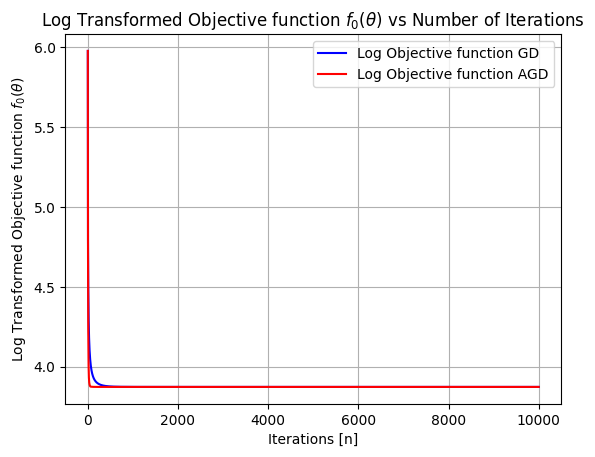

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.preprocessing import StandardScaler
X, y = sklearn.datasets.load_breast_cancer(return_X_y=True)
X_original, y_original = X.copy(), y.copy()
scaler = StandardScaler()
X = scaler.fit_transform(X) # standardize features
y = 2 * y - 1

def phi(x):
    return np.logaddexp(0, x)

def sigma(x):
    return np.exp(x) / (1 + np.exp(x))

def sigma_prime(x):
    return np.exp(x) / (1 + np.exp(x)) ** 2

def f_D(theta):
    e = np.zeros(len(theta)) # n+1 parameters
    e[-1] = 1
    return np.eye(len(theta)) - np.outer(e, e)

def lipschitz_constant(X_tilde, gamma = 3):
    return np.linalg.norm(X_tilde, ord = 2) ** 2 / 4 + gamma

def negative_log_likelihood_function(X_tilde, y_tilde, theta):
    return np.sum(phi(-np.diag(y_tilde) @ X_tilde @ theta))

def objective_function(X_tilde, y_tilde, theta, gamma=3):
    D = f_D(theta)
    return negative_log_likelihood_function(X_tilde, y_tilde, theta) + gamma / 2 * np.linalg.norm(D @ theta) ** 2

def gradient_objective_function(X_tilde, y_tilde, theta, gamma=3):
    D = f_D(theta)
    return -X_tilde.T @ np.diag(y_tilde) @ sigma(-np.diag(y_tilde) @ X_tilde @ theta) + gamma * D @ theta

def hessian_objective_function(X_tilde, y_tilde, theta, gamma = 3):
    D = f_D(theta)
    return X_tilde.T @ np.diag(sigma_prime(-np.diag(y_tilde) @ X_tilde @ theta)) @ X_tilde + gamma * D

def f_X_tilde(X: np.ndarray):
    # append column of ones to the right of X
    N = X.shape[0]
    return np.hstack([X, np.ones((N, 1))])

def f_y_tilde(y: np.ndarray):
    return y

def gradient_descent(X, y, theta_0, max_iter = 10000, tol = 1e-12, gamma = 3):
    X_tilde = f_X_tilde(X)
    y_tilde = f_y_tilde(y)
    theta = theta_0
    t = 1 / lipschitz_constant(X_tilde, gamma = gamma)
    print(f'The L is {lipschitz_constant(X_tilde, gamma = gamma):.2f}') # printing the step sizes
    print(f'The t is {1/lipschitz_constant(X_tilde, gamma = gamma):.2e}')

    # Append objective values
    objective_values = []
    last_difference = 1
    for step in range(max_iter):
        objective_values.append(objective_function(X_tilde, y_tilde, theta))
        theta_new = theta - t * gradient_objective_function(X_tilde, y_tilde, theta, gamma=3)
        last_difference = np.linalg.norm(theta_new - theta)
        if last_difference < tol:
            print(f'The tolerance of {tol} were satisfied. \nTheta: {theta}')
            return theta, np.array(objective_values)
        theta = theta_new
    print(f'The number of iterations exceeded the maximum amount of {max_iter} with last norm {last_difference:.2e}. \nTheta: {theta}')
    return theta, np.array(objective_values)

theta_0 = np.zeros(X.shape[1] + 1) # Initialize 1 for all parameters
max_iter, tol = 10000, 1e-12

# This cell runs the gradient descent optimization
theta_gradient_descent, objective_function_values_gradient_descent = gradient_descent(X, y, theta_0, max_iter = max_iter, tol = tol)


def accelerated_gradient_descent(X, y, theta_0, max_iter=10000, tol=1e-12, gamma=3):
    X_tilde = f_X_tilde(X)
    y_tilde = f_y_tilde(y)
    theta = theta_0.copy()
    y_k = theta_0.copy()
    gamma_k = 1  # Momentum parameter
    t = 1 / lipschitz_constant(X_tilde, gamma)
    print(f'The L is {lipschitz_constant(X_tilde):.2f}') # printing the step sizes
    print(f'The t is {1/lipschitz_constant(X_tilde):.2e}')

    objective_values = []
    last_difference = 1

    for step in range(max_iter):
        objective_values.append(objective_function(X_tilde, y_tilde, theta, gamma))
        theta_new = y_k - t * gradient_objective_function(X_tilde, y_tilde, y_k, gamma)
        gamma_new = (1 + np.sqrt(1 + 4 * gamma_k**2)) / 2
        y_k = theta_new + (gamma_k - 1) / gamma_new * (theta_new - theta)
        gamma_k = gamma_new
        last_difference = np.linalg.norm(theta_new - theta)
        if last_difference < tol:
            print(f'Converged at iteration {step}')
            return theta_new, np.array(objective_values)
        theta = theta_new

    print(f'The number of iterations exceeded the maximum amount of {max_iter} with last norm {last_difference:.2e}. \nTheta: {theta}')
    return theta, np.array(objective_values)

theta_accelerated_gradient_descent, objective_function_values_accelerated_gradient_descent = accelerated_gradient_descent(X, y, theta_0, max_iter = max_iter, tol = tol)

# Plot the objective function values
iterations_array_obj = np.array([i + 1 for i in range(len(objective_function_values_gradient_descent))])
iterations_array_obj_AGD = np.array([i + 1 for i in range(len(objective_function_values_accelerated_gradient_descent))])
log_transformed_objective_function_values_gradient_descent = np.log(objective_function_values_gradient_descent)
log_transformed_objective_function_values_accelerated_gradient_descent = np.log(objective_function_values_accelerated_gradient_descent)
plt.figure()
plt.plot(iterations_array_obj, log_transformed_objective_function_values_gradient_descent, color = 'blue', label = 'Log Objective function GD')
plt.plot(iterations_array_obj_AGD, log_transformed_objective_function_values_accelerated_gradient_descent, color = 'red', label = 'Log Objective function AGD')
plt.legend()
plt.xlabel(f'Iterations [n]')
plt.ylabel(r'Log Transformed Objective function $f_0(\theta)$')
plt.title(r'Log Transformed Objective function $f_0(\theta)$ vs Number of Iterations')
plt.grid('on')
plt.show()

# Task 6

[1.00000000e-03 2.06913808e-03 4.28133240e-03 8.85866790e-03
 1.83298071e-02 3.79269019e-02 7.84759970e-02 1.62377674e-01
 3.35981829e-01 6.95192796e-01 1.43844989e+00 2.97635144e+00
 6.15848211e+00 1.27427499e+01 2.63665090e+01 5.45559478e+01
 1.12883789e+02 2.33572147e+02 4.83293024e+02 1.00000000e+03]
The L is 1892.31
The t is 5.28e-04
The number of iterations exceeded the maximum amount of 10000 with last norm 1.23e-03. 
Theta: [ 20.0384076   -0.86581901  11.28385735 -16.50744332  -3.37383028
  13.80891147 -12.11244175  -6.59734539   2.18384479  -1.44284485
  -7.54027424   2.31659576   7.35257684 -12.0893567   -0.71923239
  -6.72868389   9.39376055  -9.93283781   2.77705187  12.77968755
  -6.66388608  -5.08144145  -9.92252148 -14.3132181    1.28653225
   3.71224964  -4.69521111   0.24949783  -4.796782    -8.45643998
  -5.25963386]
The L is 1892.31
The t is 5.28e-04
The number of iterations exceeded the maximum amount of 10000 with last norm 4.99e-04. 
Theta: [ 12.3702691   -0.43328

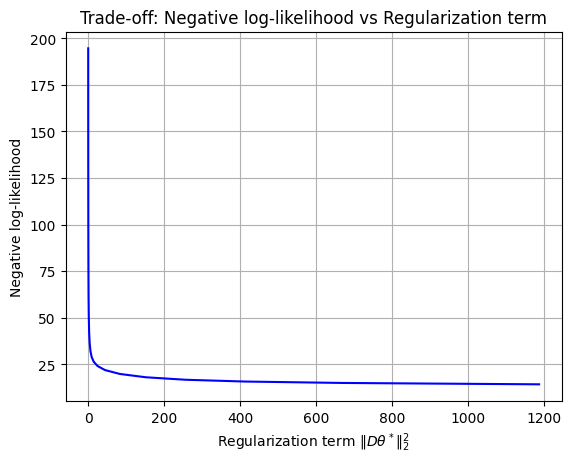

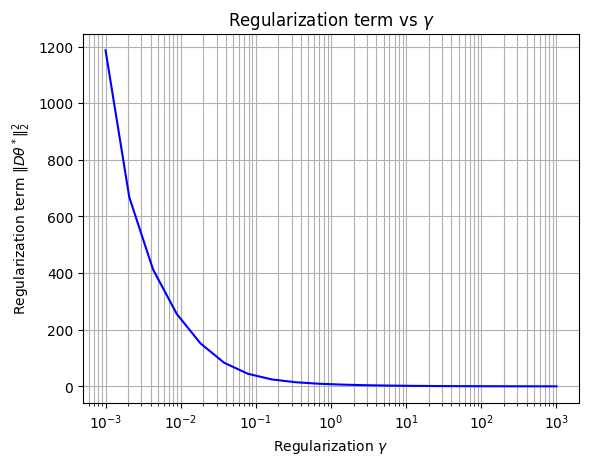

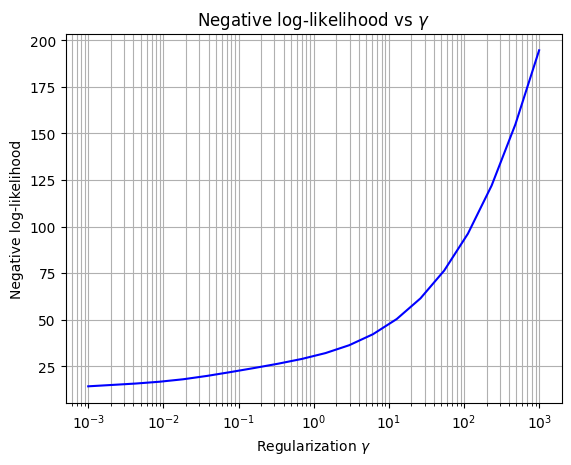

In [18]:
def trade_off(X_tilde, y_tilde, optimization_method, gamma_log_range):
    regularization_terms, negative_log_likelihood_terms = [], []
    theta_current = np.zeros(X_tilde.shape[1])
    for gamma_val in gamma_log_range:
        theta_star, _ = optimization_method(X, y, theta_current, max_iter=max_iter, tol = tol, gamma = gamma_val)
        theta_current = theta_star
        reg_term = 1 / 2 * np.sum((f_D(theta_star) @ theta_star) ** 2)
        negative_log_likelihood = negative_log_likelihood_function(X_tilde, y_tilde, theta_star)
        regularization_terms.append(reg_term)
        negative_log_likelihood_terms.append(negative_log_likelihood)
    return regularization_terms, negative_log_likelihood_terms

def compute_trade_off(X, y):
    gamma_log_range = np.logspace(-3, 3, 20)
    print(gamma_log_range)
    X_tilde = f_X_tilde(X)
    y_tilde = f_y_tilde(y)
    regularization_terms, negative_log_likelihood_terms = trade_off(X_tilde, y_tilde, optimization_method = accelerated_gradient_descent, gamma_log_range = gamma_log_range)
    return gamma_log_range, regularization_terms, negative_log_likelihood_terms

gamma_log_range, regularization_terms, negative_log_likelihood_terms = compute_trade_off(X, y)
print(gamma_log_range)
print(regularization_terms)
print(negative_log_likelihood_terms)

def plot_trade_off(gamma_log_range, regularization_terms, negative_log_likelihood_terms):
    # Plot trade-off
    plt.figure()
    plt.plot(regularization_terms, negative_log_likelihood_terms, color='blue')
    plt.xlabel('Regularization term $\\|D\\theta^*\\|_2^2$')
    plt.ylabel('Negative log-likelihood')
    plt.title('Trade-off: Negative log-likelihood vs Regularization term')
    plt.grid(True)
    plt.show()

    # Plot regularization term vs gamma
    plt.figure()
    plt.plot(gamma_log_range, regularization_terms, color='blue')
    plt.xscale('log') 
    plt.xlabel('Regularization $\\gamma$')
    plt.ylabel('Regularization term $\\|D\\theta^*\\|_2^2$')
    plt.title('Regularization term vs $\\gamma$')
    plt.grid(True, which='both')
    plt.show()

    # Plot negative log-likelihood vs gamma
    plt.figure()
    plt.plot(gamma_log_range, negative_log_likelihood_terms, color='blue')
    plt.xscale('log')  
    plt.xlabel('Regularization $\\gamma$')
    plt.ylabel('Negative log-likelihood')
    plt.title('Negative log-likelihood vs $\\gamma$')
    plt.grid(True, which='both')
    plt.show()

plot_trade_off(gamma_log_range, regularization_terms, negative_log_likelihood_terms)